In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import h5py
from pathlib import Path

path = Path(run.rundir) / "149p6.000.dat"

with h5py.File(path, "r") as h5:
    print("Top-level names:", list(h5.keys()))
    print("File attributes:", dict(h5.attrs))

    def describe(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(name, obj.shape, obj.dtype)

    h5.visititems(describe)

Top-level names: ['T_e', 'T_i', 'b0x', 'b0y', 'b0z', 'betae', 'betai', 'bx', 'by', 'bz', 'c_2', 'ex', 'ey', 'ez', 'jex', 'jey', 'jez', 'jix', 'jiy', 'jiz', 'jx', 'jy', 'jz', 'lambdae', 'lx', 'ly', 'lz', 'm_e', 'n_0', 'ne', 'ni', 'nx', 'ny', 'nz', 'pexx', 'pexy', 'pexz', 'peyy', 'peyz', 'pezz', 'pixx', 'pixy', 'pixz', 'piyy', 'piyz', 'pizz', 'rho', 'rhoe', 'rhoi', 'time', 'vthe', 'vthi', 'wce', 'wci', 'wpe', 'wpi', 'xx', 'yy', 'zz']
File attributes: {}
T_e () float64
T_i () float64
b0x () float64
b0y () float64
b0z () float64
betae () float64
betai () float64
bx (4096, 4096, 1) float32
by (4096, 4096, 1) float32
bz (4096, 4096, 1) float32
c_2 () float64
ex (4096, 4096, 1) float32
ey (4096, 4096, 1) float32
ez (4096, 4096, 1) float32
jex (4096, 4096, 1) float32
jey (4096, 4096, 1) float32
jez (4096, 4096, 1) float32
jix (4096, 4096, 1) float32
jiy (4096, 4096, 1) float32
jiz (4096, 4096, 1) float32
jx (4096, 4096, 1) float32
jy (4096, 4096, 1) float32
jz (4096, 4096, 1) float32
lambdae (

In [ ]:
from turbos.sim.p3d.p3d_1 import p3d


vars = [
    "ne", "jex", "jey", "jez",
    "pexx", "pexy", "pexz", "peyy", "peyz", "pezz",
    "ni", "jix", "jiy", "jiz",
    "pixx", "pixy", "pixz", "piyy", "piyz", "pizz",
]

# run =p3d('/archive/tulasi/149p6_rs/', filenum= '000')
run =p3d('/archive/tulasi/MEGARUNS_DATA_SUBSET/149p6', filenum= '000')
print(run.nx, run.ny, run.nz, run.data_type)
raw = run.load_xarray(0, variables=['bx'])

print(raw)
print(raw.x.values[:5], raw.y.values[:5])
print(raw.attrs)

4096 4096 1 f
<xarray.Dataset> Size: 134MB
Dimensions:  (x: 4096, y: 4096)
Coordinates:
  * x        (x) float64 33kB 0.0 0.03651 0.07303 0.1095 ... 149.5 149.5 149.5
  * y        (y) float64 33kB 0.0 0.03651 0.07303 0.1095 ... 149.5 149.5 149.5
Data variables:
    bx       (x, y) float64 134MB -0.1983 -0.1954 -0.1919 ... -0.2104 -0.2062
Attributes:
    time:     0.0
    run:      149p6_rs
    slice:    0
    dtmovie:  0.005
[0.         0.03651484 0.07302969 0.10954453 0.14605937] [0.         0.03651484 0.07302969 0.10954453 0.14605937]
{'time': 0.0, 'run': '149p6_rs', 'slice': 0, 'dtmovie': 0.005}


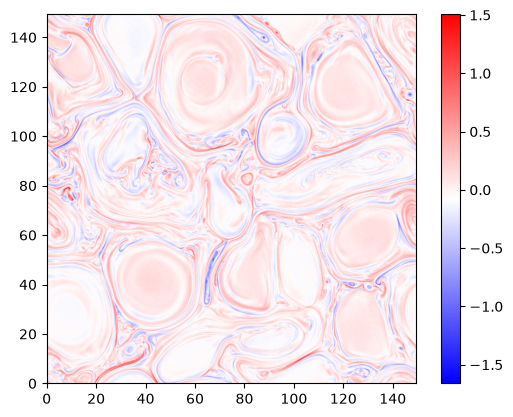

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(raw['jez'], cmap = 'bwr', origin='lower', extent=[raw.x.values[0], raw.x.values[-1], raw.y.values[0], raw.y.values[-1]])
plt.colorbar()
plt.show()